In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())
misc_params = Params.additional_misc_params()

from datetime import date
from dateutil.relativedelta import relativedelta

Loading packages...


In [2]:
print('Setting parameters...')
run_params = Params.standard_set_1pctCO2cdr()  #Params.test_set_1pctCO2cdr() #

Setting parameters...


In [3]:
ds_atmCO2 = MiscDataGetter._get_atmospheric_CO2(run_params)

james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2


In [4]:
ds0 = xr.open_dataset('/data/ekoehn/CMIP6_derived/co2/1pctCO2/Amon/co2_Amon_CanESM5_1pctCO2_r1i1p2f1_gn_185001-200012.nc')

ds5 = xr.open_dataset('/data/ekoehn/CMIP6_derived/co2s/1pctCO2/Emon/co2s_Emon_GFDL-ESM4_1pctCO2_r1i1p1f1_gr1_000101-015012.nc')
ds5_dn = xr.open_dataset('/data/ekoehn/CMIP6_derived/co2s/1pctCO2-cdr/Emon/co2s_Emon_GFDL-ESM4_1pctCO2-cdr_r1i1p1f1_gr1_014101-034012.nc')
ds5_area = xr.open_dataset('/data/ekoehn/CMIP6_derived/areacella/1pctCO2/fx/areacella_fx_GFDL-ESM4_1pctCO2_r1i1p1f1_gr1.nc')

ds1 = xr.open_dataset('/data/ekoehn/CMIP6_derived/co2/1pctCO2/Amon/co2_Amon_CNRM-ESM2-1_1pctCO2_r1i1p1f2_gr_185001-199912.nc')
ds1_dn = xr.open_dataset('/data/ekoehn/CMIP6_derived/co2/1pctCO2-cdr/Amon/co2_Amon_CNRM-ESM2-1_1pctCO2-cdr_r1i1p1f2_gr_199001-218912.nc')
ds1_area = xr.open_dataset('/data/ekoehn/CMIP6_derived/areacella/1pctCO2/fx/areacella_fx_CNRM-ESM2-1_1pctCO2_r1i1p1f2_gr.nc')

ds4 = xr.open_dataset('/data/ekoehn/CMIP6_derived/co2/1pctCO2/Amon/co2_AERmon_MIROC-ES2L_1pctCO2_r1i1p1f2_gn_185001-199912.nc')
ds4_area = xr.open_dataset('/data/ekoehn/CMIP6_derived/areacella/1pctCO2/fx/areacella_fx_MIROC-ES2L_1pctCO2_r1i1p1f2_gn.nc')

ds3 = xr.open_dataset('/data/ekoehn/CMIP6_derived/co2/1pctCO2/Amon/co2_Amon_CESM2_1pctCO2_r1i1p1f1_gn_000101-015012.nc')
ds3_dn = xr.open_dataset('/data/ekoehn/CMIP6_derived/co2/1pctCO2-cdr/Amon/co2_Amon_CESM2_1pctCO2-cdr_r1i1p1f1_gn_000101-020012.nc')
ds3_area = xr.open_dataset('/data/ekoehn/CMIP6_derived/areacella/1pctCO2/fx/areacella_fx_CESM2_1pctCO2_r1i1p1f1_gn.nc')

ds2 = xr.open_dataset('/data/ekoehn/CMIP6_derived/co2/1pctCO2/Amon/co2_Amon_NorESM2-LM_1pctCO2_r1i1p1f1_gn_000101-015012.nc')
ds2_dn = xr.open_dataset('/data/ekoehn/CMIP6_derived/co2/1pctCO2-cdr/Amon/co2_Amon_NorESM2-LM_1pctCO2-cdr_r1i1p1f1_gn_014101-039912.nc')
ds2_area = xr.open_dataset('/data/ekoehn/CMIP6_derived/areacella/1pctCO2/fx/areacella_fx_1pctCO2_NorESM2-LM_r1i1p1f1_gn.nc')


In [5]:
### CanESM5
print('CanESM5')
ds0 = ds0.assign_coords(year=('time', ds0.time.dt.year.values))
ds0_yearly = ds0.groupby('year').mean('time')

### CNRM-ESM2-1
print('CNRM-ESM2-1')
ds1 = ds1.assign_coords(year=('time', ds1.time.dt.year.values))
ds1_dn = ds1_dn.assign_coords(year=('time', ds1_dn.time.dt.year.values))

ds1_spat_avg = ds1.co2.weighted(ds1_area.areacella).mean(dim=('lat','lon'))
ds1_dn_spat_avg = ds1_dn.co2.weighted(ds1_area.areacella).mean(dim=('lat','lon'))

ds1_yearly = ds1_spat_avg.groupby('year').mean('time').isel(plev=0)
ds1_dn_yearly = ds1_dn_spat_avg.groupby('year').mean('time').isel(plev=0)

### GFDL-ESM4
print('GFDL-ESM4')
ds5 = ds5.assign_coords(year=('time', ds5.time.dt.year.values))
ds5_dn = ds5_dn.assign_coords(year=('time', ds5_dn.time.dt.year.values))

ds5_spat_avg = ds5.co2s.weighted(ds5_area.areacella).mean(dim=('lat','lon'))
ds5_dn_spat_avg = ds5_dn.co2s.weighted(ds5_area.areacella).mean(dim=('lat','lon'))

ds5_yearly = ds5_spat_avg.groupby('year').mean('time')
ds5_dn_yearly = ds5_dn_spat_avg.groupby('year').mean('time')

### MIROC
print('MIROC')
ds4 = ds4.assign_coords(year=('time', ds4.time.dt.year.values))
ds4_spat_avg = ds4.co2.weighted(ds4_area.areacella).mean(dim=('lat','lon'))
ds4_yearly = ds4_spat_avg.groupby('year').mean('time')

### CESM2
print('CESM2')
ds3 = ds3.assign_coords(year=('time', ds3.time.dt.year.values))
ds3_spat_avg = ds3.co2.weighted(ds3_area.areacella).mean(dim=('lat','lon'))
ds3_yearly = ds3_spat_avg.groupby('year').mean('time')

ds3_dn = ds3_dn.assign_coords(year=('time', ds3_dn.time.dt.year.values))
ds3_dn_spat_avg = ds3_dn.co2.weighted(ds3_area.areacella).mean(dim=('lat','lon'))
ds3_dn_yearly = ds3_dn_spat_avg.groupby('year').mean('time')

### NorESM2
print('NorESM2')
ds2 = ds2.assign_coords(year=('time', ds2.time.dt.year.values))
ds2_spat_avg = ds2.co2.weighted(ds2_area.areacella).mean(dim=('lat','lon'))
ds2_yearly = ds2_spat_avg.groupby('year').mean('time')

ds2_dn = ds2_dn.assign_coords(year=('time', ds2_dn.time.dt.year.values))
ds2_dn_spat_avg = ds2_dn.co2.weighted(ds2_area.areacella).mean(dim=('lat','lon'))
ds2_dn_yearly = ds2_dn_spat_avg.groupby('year').mean('time')

CanESM5
CNRM-ESM2-1
GFDL-ESM4
MIROC
CESM2
NorESM2


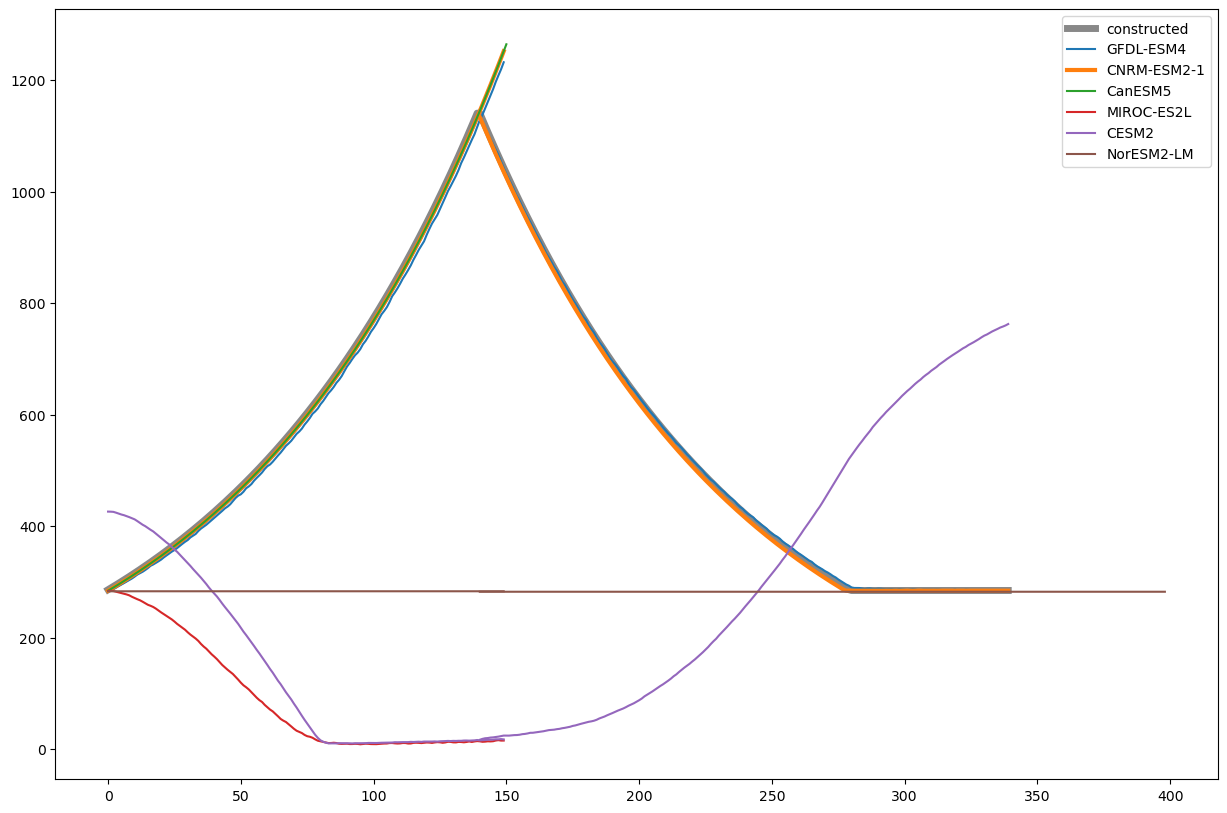

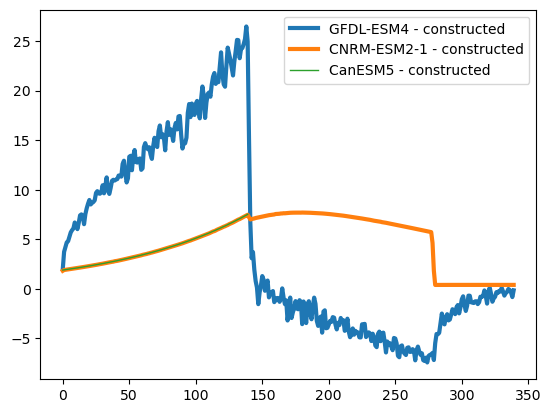

In [6]:
fig, ax = plt.subplots(figsize=(15,10))
plt.plot(np.arange(340),ds_atmCO2['2'].isel(year=slice(0,340)),linewidth=5,color='#888888',label='constructed')
plt.plot(np.arange(150),ds5_yearly,color='C0',label='GFDL-ESM4')#.plot()
plt.plot(np.arange(140,340),ds5_dn_yearly,color='C0')#.plot()
plt.plot(np.arange(150),ds1_yearly*1e6,color='C1',linewidth=3,label='CNRM-ESM2-1')#.plot()
plt.plot(np.arange(140,340),ds1_dn_yearly*1e6,color='C1',linewidth=3)#.plot()
plt.plot(np.arange(151),ds0_yearly.co2.isel(lon=0,lat=0,plev=0),color='C2',label='CanESM5')
plt.plot(np.arange(150),ds4_yearly.isel(lev=0)*1e6,color='C3',label='MIROC-ES2L')
plt.plot(np.arange(150),ds3_yearly.isel(plev=0)*1e6,color='C4',label='CESM2')
plt.plot(np.arange(140,340),ds3_dn_yearly.isel(plev=0)*1e6,color='C4')
plt.plot(np.arange(150),ds2_yearly.isel(plev=0)*1e6,color='C5',label='NorESM2-LM')
plt.plot(np.arange(140,399),ds2_dn_yearly.isel(plev=0)*1e6,color='C5')
plt.legend()
plt.show()

fig, ax = plt.subplots()
concat_ds5 = xr.concat([ds5_yearly.isel(year=slice(0,140)),ds5_dn_yearly],dim='year')
concat_ds5 = concat_ds5.assign_coords(year=concat_ds5['year'] + 1849)
concat_ds1 = xr.concat([ds1_yearly.isel(year=slice(0,140)),ds1_dn_yearly],dim='year')
#concat_ds1 = concat_ds1.assign_coords(year=concat_ds1['year'] + 1849)
ax.plot(ds_atmCO2['2'].isel(year=slice(0,340)) - concat_ds5,linewidth=3,color='C0',label='GFDL-ESM4 - constructed')
ax.plot(ds_atmCO2['2'].isel(year=slice(0,340)) - concat_ds1*1e6,linewidth=3,color='C1',label='CNRM-ESM2-1 - constructed')
ax.plot(ds_atmCO2['2'].isel(year=slice(0,140)) - ds0_yearly.co2.isel(lon=0,lat=0,plev=0,year=slice(0,140)),linewidth=1,color='C2',label='CanESM5 - constructed')
plt.legend()

In [7]:
LONCHO = 200
LATCHO = 0
PLEVCHO = 0

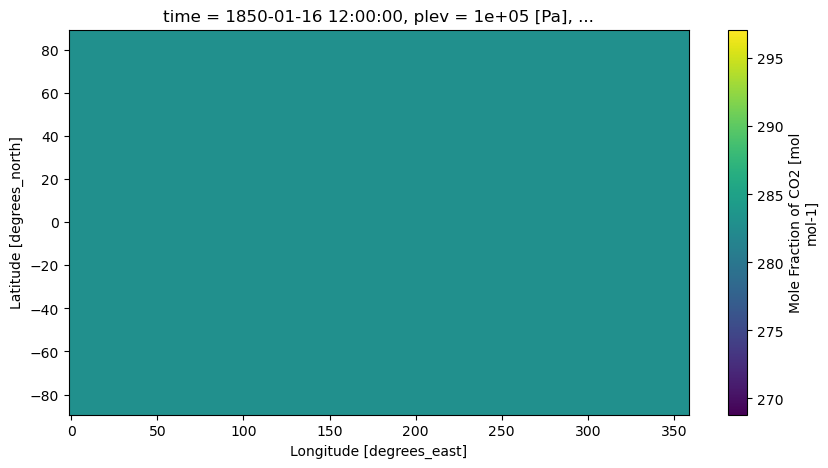

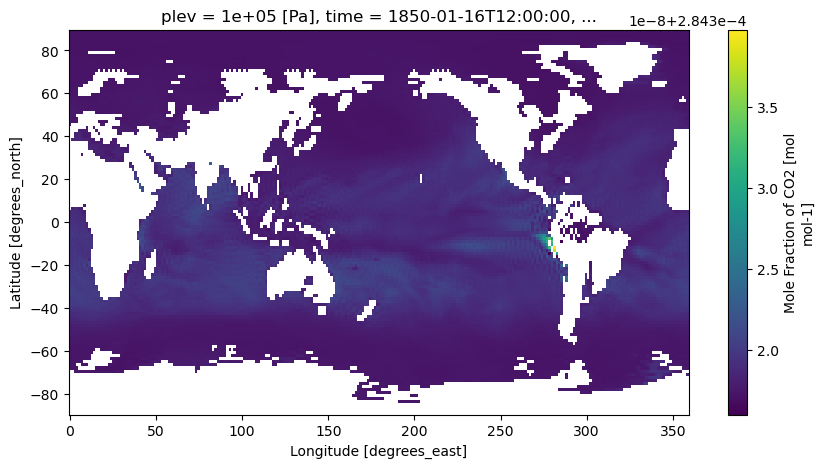

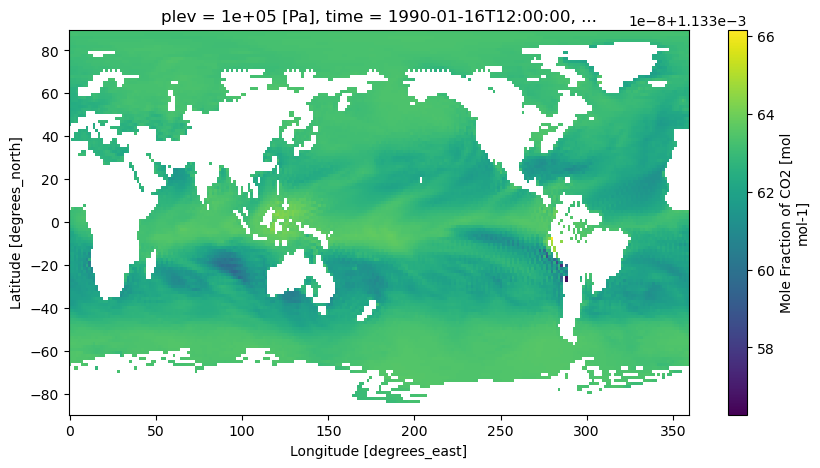

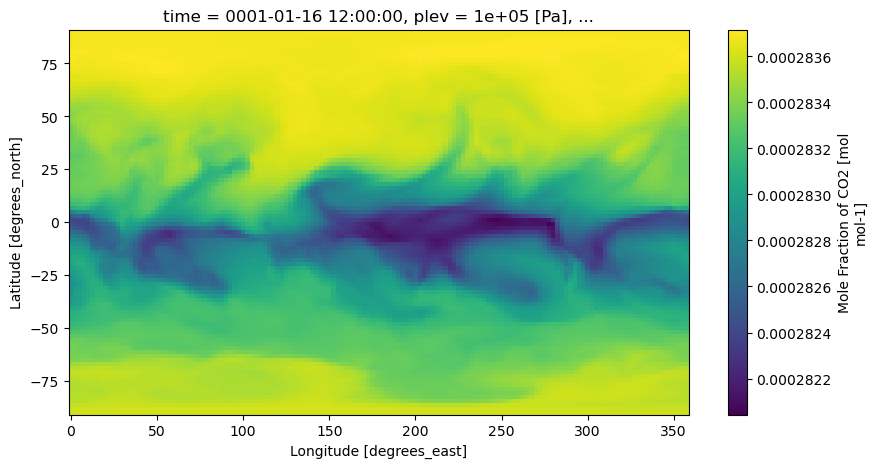

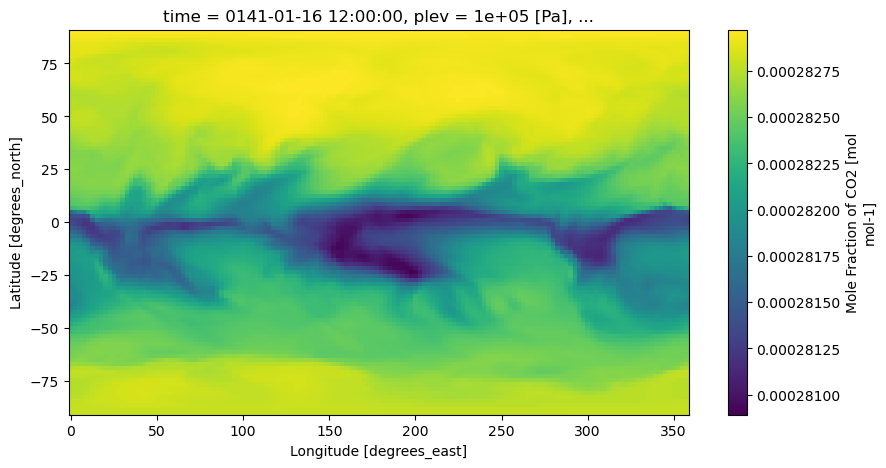

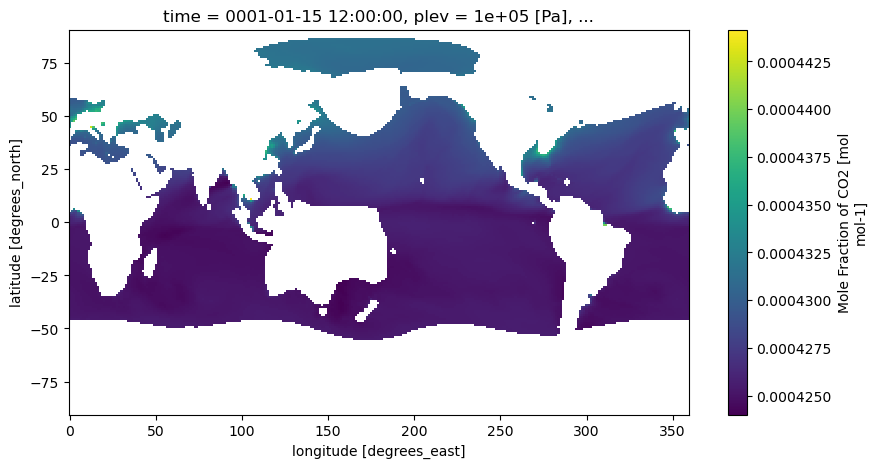

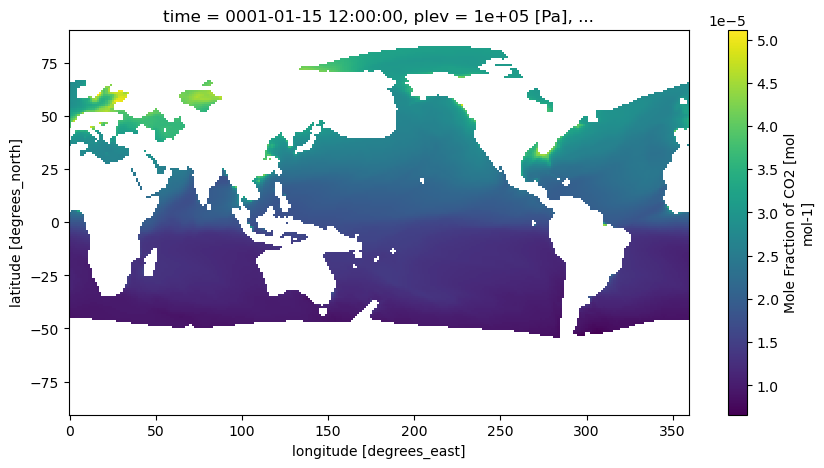

In [8]:
ds0.co2.isel(time=0,plev=PLEVCHO).plot(figsize=(10,5))

ds1.co2.isel(time=0,plev=PLEVCHO).plot(figsize=(10,5))
ds1_dn.co2.isel(time=0,plev=PLEVCHO).plot(figsize=(10,5))

ds2.co2.isel(time=0,plev=PLEVCHO).plot(figsize=(10,5))
ds2_dn.co2.isel(time=0,plev=PLEVCHO).plot(figsize=(10,5))

ds3.co2.isel(time=0,plev=PLEVCHO).plot(figsize=(10,5))
ds3_dn.co2.isel(time=0,plev=PLEVCHO).plot(figsize=(10,5))


In [9]:
1

1